# Decision Tree and Random Forest Model: Prediction of the quantity to order

Decision Tree Regression will be used as the first advanced machine-learning model to predict the quantity of malaria commodities approved by the central supply chain (`quantity_approved`) from a set of inventory, product, facility, geographic, and temporal predictors.

The previous Multiple Linear Regression analysis established an interpretable baseline but demonstrated relatively limited predictive performance, explaining 14% of the variability in approved quantities.

Decision Tree Regression is therefore introduced as a more flexible modeling approach because it can capture non-linear relationships, interactions between predictors, and threshold-based patterns without requiring the linearity, residual normality, and homoscedasticity assumptions associated with MLR. 

To ensure a fair comparison with the MLR baseline, the Decision Tree will be developed using the same training and test observations, and its predictive performance will be evaluated using the same metrics: R², MAE, MSE, and RMSE.

The analysis will consist of three main stages:

1. Building and evaluating a baseline Decision Tree, to assess its initial predictive performance and identify potential overfitting;
2. Optimizing and evaluating the Decision Tree, by controlling model complexity through hyperparameters such as tree depth, minimum samples required for splitting, minimum samples per leaf, and pruning;
3. Interpreting and comparing the model results, including feature importance and comparison of training and test performance against the MLR reference model.

The primary modeling concern therefore shifts from verifying these statistical assumptions to controlling model complexity and overfitting, while assessing whether the model generalizes effectively to unseen data.

## 1.Import libraries and loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Displays the splits of the tree
from sklearn.tree import plot_tree

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, mean_absolute_error,mean_squared_error,r2_score

# Loading the data
df_x_train=pd.read_csv('../data/x_train.csv')
df_x_test=pd.read_csv('../data/x_test.csv')
df_y_train=pd.read_csv('../data/y_train.csv')
df_y_test=pd.read_csv('../data/y_test.csv')

### df_x_train.info()

In [2]:
df_x_train.head()

,Unnamed: 0,beginning_balance,quantity_received,quantity_dispensed,total_losses_and_adjustments,stock_in_hand,months_of_stock,amc,product_group_ART,product_group_DIAG,...,facility_type_HOSPITAL,reporting_month_February,reporting_month_May,reporting_month_November,zone_type_URBAN,High_Transmission_Preparation_YES,stock_status_Critical,stock_status_Low,stock_status_Overstock,stock_status_Stockout
0,2839,560.0,1002.0,381.0,-179,1456.0,6.2,233.0,0,0,...,0,0,1,0,0,1,0,0,1,0
1,5726,2928.0,746.0,854.0,-545,3548.0,2.6,1374.0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,5590,1134.0,154.0,467.0,-569,2469.0,8.9,277.0,0,0,...,0,1,0,0,0,0,0,0,1,0
3,2726,8559.0,66.0,1795.0,-236,6138.0,2.6,2361.0,0,0,...,0,0,0,0,1,1,0,1,0,0
4,6219,544.0,0.0,16.0,-258,300.0,100.0,3.0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [3]:
df_x_test.head()

,Unnamed: 0,beginning_balance,quantity_received,quantity_dispensed,total_losses_and_adjustments,stock_in_hand,months_of_stock,amc,product_group_ART,product_group_DIAG,...,facility_type_HOSPITAL,reporting_month_February,reporting_month_May,reporting_month_November,zone_type_URBAN,High_Transmission_Preparation_YES,stock_status_Critical,stock_status_Low,stock_status_Overstock,stock_status_Stockout
0,5142,272.0,0.0,4.0,-783,168.0,168.0,1.0,0,1,...,0,0,0,0,1,1,0,0,1,0
1,3307,424.0,65.0,123.0,-331,122.0,2.3,53.0,0,0,...,0,0,1,0,1,1,0,1,0,0
2,4280,3873.0,18.0,1335.0,52,2727.0,2.2,1245.0,0,0,...,0,1,0,0,1,0,0,1,0,0
3,8321,4545.0,19.0,351.0,251,2030.0,7.4,274.0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,6600,548.0,0.0,191.0,-754,264.0,1.2,218.0,0,0,...,0,0,0,1,0,0,0,1,0,0


We can see that, the column 'Unmaned" which is simply an index accidentally imported from CSV, let's remove it as it could be interpreted by the model as a variable.

In [4]:
df_x_train = df_x_train.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

df_x_test = df_x_test.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

df_y_train = df_y_train.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

df_y_test = df_y_test.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

In [5]:
df_y_train

,quantity_approved
0,448.0
1,35.0
2,400.0
3,4450.0
4,1.0
...,...
6779,1025.0
6780,6839.0
6781,49.0
6782,5.0


## 2.Construct the model


In [6]:
# Instantiate the model
decision_tree = DecisionTreeRegressor(random_state=0)

# Fit the model to training data
decision_tree.fit(df_x_train, df_y_train)

# Make predictions on test data
y_test_pred_dt = decision_tree.predict(df_x_test)

In [7]:
# Generate performance metrics
print("r2:", "%.3f" % r2_score(df_y_test, y_test_pred_dt))
print("MAE:", "%.3f" % mean_absolute_error(df_y_test, y_test_pred_dt))
print("MSE:", "%.3f" % np.sqrt( mean_squared_error(df_y_test, y_test_pred_dt)))
#print("F1 Score:", "%.3f" % f1_score(dfy_test, y_test_pred_dt))

r2: -0.776
MAE: 1328.725
MSE: 2727.392


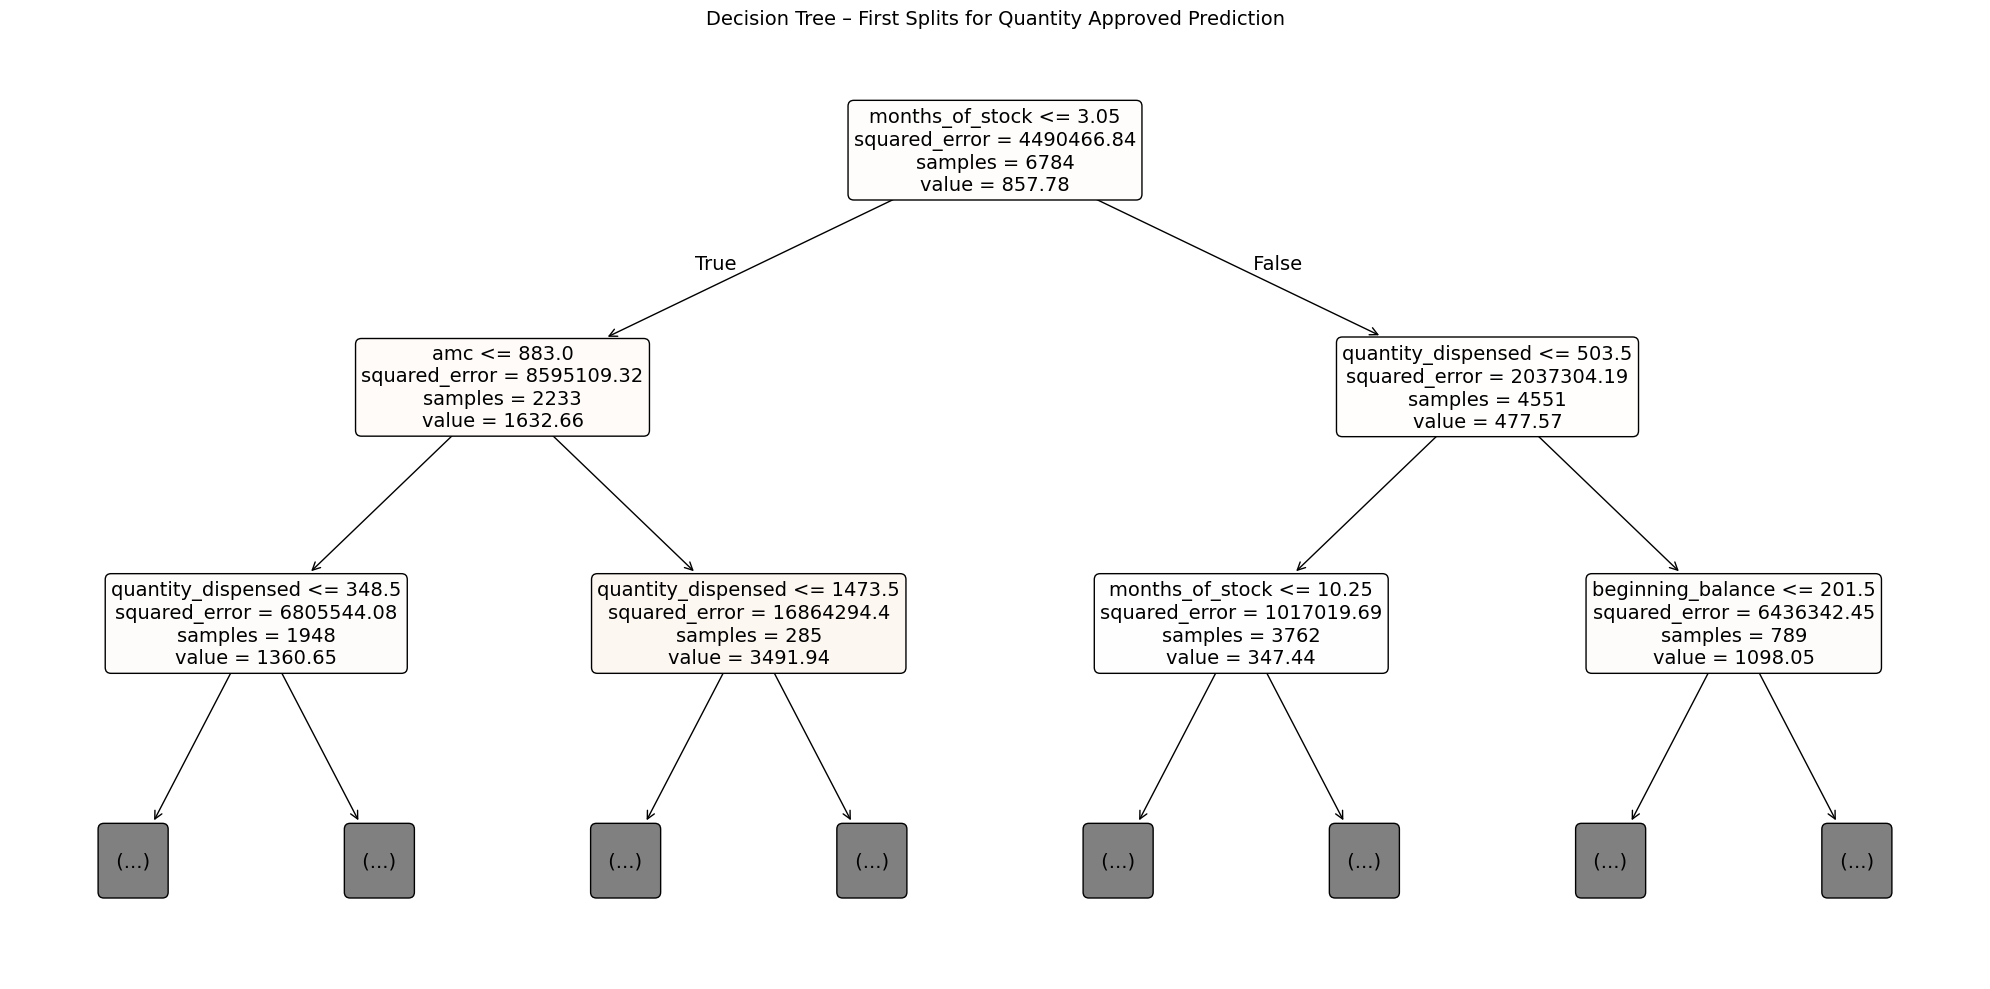

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree,
    max_depth=2,
    feature_names=df_x_train.columns,
    filled=True,
    rounded=True,
    fontsize=14,
    precision=2
)

plt.title(
    "Decision Tree – First Splits for Quantity Approved Prediction",
    fontsize=14
)

plt.tight_layout()
plt.show()

* Visualization of the upper levels of the baseline Decision Tree shows that months_of_stock is selected as the root predictor. The fact that the Decision Tree independently selects months_of_stock as its root predictor suggests that this engineered feature contains useful predictive information that is not captured as effectively by considering stock and consumption only as separate variables
* The threshold of 3.05 months at the root node divides observations into two substantially different groups:
    * MoS ≤ 3.05: 2,233 observations, average approved quantity = 1,632.66 units
    * MoS > 3.05: 4,551 observations, average approved quantity = 477.57 units
    * This is a particularly meaningful result from a supply-chain perspective. Facilities with products with approximately three months of stock or less receive substantially larger approved quantities on average than those with more than three months of stock.
* the node with amc <= 883, is separated into 2 observations:
    * AMC ≤ 883: 1,948 observations with average approval = 1,360.65
    * AMC > 883: 285 observations with average approval = 3,491.94
    * This indicates an interaction between stock coverage and consumption. Among observations already characterized by relatively low stock coverage, those with very high AMC receive much larger approved quantities.
* At the next level of the node amc <= 883, quantity_dispensed becomes the splitting variable: quantity_dispensed ≤ 348.5 and quantity_dispensed ≤ 1473.5. This shows that current-period dispensing provides additional information once stock coverage and average consumption have already been considered.
* For observations with more than 3.05 months of stock, the model next uses `quantity_dispensed <= 503.5`. The average approved quantity for this entire branch is only 477.57 units, substantially below the 1,632.66 units observed in the low-stock branch. this node is then separated in subgroup using MOS and beginning_balance. The fact that MoS appears again, demonstrating that stock coverage remains useful even after the initial 3.05-month threshold.

This tree  provides evidence that the allocation process is not simply associated with one inventory variable independently. Instead, the Decision Tree identifies **conditional interactions between inventory position and consumption**

## 3.Tune the model

### 3.1. Decision Tree model

In [9]:
from sklearn.model_selection import GridSearchCV
decision_tree = None
decision_tree = DecisionTreeRegressor(random_state=0)

#Grid searches combinations of four hyperparameters:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"]
}
scoring = {'neg_mean_absolute_error'}
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)


grid_search.fit(df_x_train, df_y_train)
print("Best parameters:", grid_search.best_params_)
print("Best estimator:", grid_search.best_estimator_)
print("Best CV MAE:",-grid_search.best_score_)

Best parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best estimator: DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=0)
Best CV MAE: 1025.1220413530616


In [10]:

#Then retrieve the tuned model:
dt_tuned = grid_search.best_estimator_

# evaluate it on both datasets:
# Predictions
y_train_pred_dt = dt_tuned.predict(df_x_train)
y_test_pred_dt = dt_tuned.predict(df_x_test)

In [11]:
def evaluate_model(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        )
    }

In [12]:
print(
    "Training:",
    evaluate_model(df_y_train, y_train_pred_dt)
)
print(
    "Test:",
    evaluate_model(df_y_test, y_test_pred_dt)
)
dt_result_test=  evaluate_model(df_y_test, y_test_pred_dt)

Training: {'R2': 0.18556525030039117, 'MAE': 982.7926617569582, 'RMSE': np.float64(1912.3786845288869)}
Test: {'R2': 0.11997472085953043, 'MAE': 1014.086060460536, 'RMSE': np.float64(1919.7377592258906)}


In [13]:
dt_result_test

{'R2': 0.11997472085953043,
 'MAE': 1014.086060460536,
 'RMSE': np.float64(1919.7377592258906)}

### Feature importance attributes

In [28]:
importances = dt_tuned.feature_importances_
dt_importances = pd.Series(importances, index=df_x_test.columns)
dt_importances = dt_importances.sort_values(ascending=False)

In [29]:
dt_importances

months_of_stock                      0.443070
amc                                  0.215213
quantity_dispensed                   0.214675
stock_in_hand                        0.089368
total_losses_and_adjustments         0.019628
beginning_balance                    0.013406
quantity_received                    0.004640
product_group_ART                    0.000000
product_group_DIAG                   0.000000
product_group_PREV                   0.000000
product_group_PYRA                   0.000000
product_group_SP                     0.000000
facility_type_HOSPITAL               0.000000
reporting_month_February             0.000000
reporting_month_May                  0.000000
reporting_month_November             0.000000
zone_type_URBAN                      0.000000
High_Transmission_Preparation_YES    0.000000
stock_status_Critical                0.000000
stock_status_Low                     0.000000
stock_status_Overstock               0.000000
stock_status_Stockout             

In [30]:
dt_importances = dt_importances.sort_values(ascending=False)[:7]
dt_importances = (dt_importances * 100)

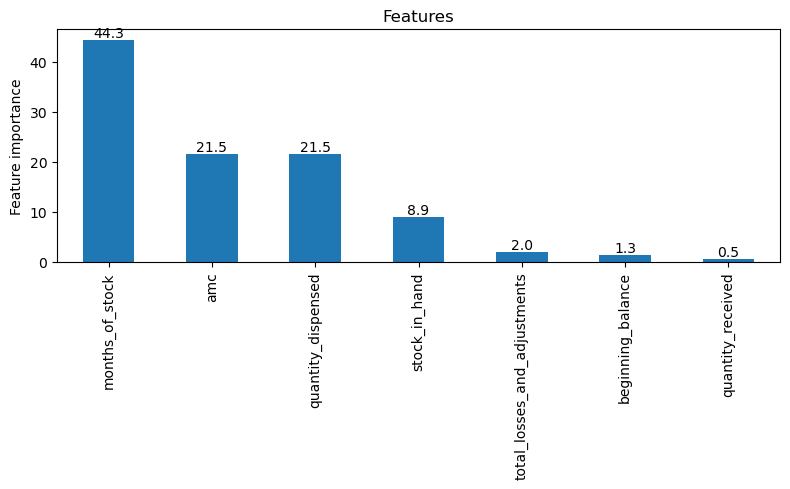

In [31]:
fig, ax = plt.subplots(figsize=(8,5))
dt_importances.plot.bar(ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.1f}')
ax.set_title('Features')
ax.set_ylabel('Feature importance')
fig.tight_layout();

In [32]:
dt_importances_consumption = dt_importances[['months_of_stock','amc',
    'quantity_dispensed','stock_in_hand']]
dt_importances_consumption

months_of_stock       44.306986
amc                   21.521347
quantity_dispensed    21.467518
stock_in_hand          8.936757
dtype: float64

In [33]:

total_feature_importance= dt_importances_consumption.sum()
print(f'Consumption related features importance {total_feature_importance:.2f}%')

Consumption related features importance 96.23%


In [34]:
print(f'Movement related features importance {100 - total_feature_importance:.2f}%')

Movement related features importance 3.77%


* Feature-importance analysis of the tuned Decision Tree indicates that Months of Stock is the most influential predictor, accounting for approximately 44.3% of total feature importance, followed by AMC (21.5%), quantity dispensed (21.5%), and stock in hand (8.9%).Together, these predictor related to the consumption and stock level account for approximately 96.2% of the model's total feature importance.
* While Months of Stock is consistent with the tree structure, where MoS was selected as the root predictor with an initial threshold of approximately 3.05 months. it exhibited only a small linear coefficient in the MLR model, suggesting that its relationship with approved quantity is non-linear or adequately represented by a single linear slope.
* Total losses and adjustments, Beginning balance, Quantity received contribute only about 3.8% collectively which show that they played a relatively minor role in the final tuned tree (< 5%)
* A striking result is that all categorical predictors have zero feature importance, including product group, facility type, reporting month, geographic zone, high-transmission preparation period, and stock-status categories. This does not demonstrate that product group, facility type, reporting month, geographic location, seasonality, or stock status have no relationship with approved quantities. Rather, these variables did not provide sufficient additional reduction in prediction error to be selected within the constrained tree. Some of their information may also be indirectly captured by continuous inventory variables. This is particularly relevant for stock status, which is derived directly from Months of Stock.
* As the tree has been deliberately constrained to max_depth = 5 and min_samples_leaf = 20, the algorithm gives priority to predictors that produce the greatest reductions in squared error. Continuous inventory variables captured the available predictive signal before the categorical variables could provide sufficient additional improvement.
* This produces an interesting contrast between the two models: MLR and Decision Tree. In MLR, several categorical variables received sizeable coefficients, for example, Critical and Low stock status—because MLR estimates a coefficient for every included dummy variable. The Decision Tree behaves differently. A variable receives importance only if it is actually selected for one or more splits. The tuned tree found that continuous stock and consumption variables were sufficient to construct its most useful decision rules. This difference illustrates why MLR coefficients and Decision Tree feature importance should not be directly compared as equivalent measures. MLR coefficients describe conditional linear associations; tree importance measures how much selected splits reduce prediction error.

In [21]:
mlr_result=pd.DataFrame({'model': ['MLR'],
                        'R2': [0.15],
                        'MAE': [1019.58],
                        'RMSE': [1883.14],
                        })

#dt_result = pd.DataFrame([dt_result_test]).rename(columns={'RMSE': 'RMSR'})
dt_result = pd.DataFrame([dt_result_test])

In [22]:
dt_result

,R2,MAE,RMSE
0,0.119975,1014.08606,1919.737759


In [44]:
dt_result=dt_result.round(2)
dt_result['model'] = 'Decision Tree'
results_model = pd.concat([mlr_result,dt_result])
results_model.reset_index(inplace=True,drop=True)

In [45]:
results_model

,model,R2,MAE,RMSE
0,MLR,0.15,1019.58,1883.14
1,Decision Tree,0.12,1014.09,1919.74


* R2(MLR) = 0.15 > 0.12, on the unseen data even though the Decision Tree fits the training dataset better (0.18  > 0.14 ). MLR therefore explains slightly more of the variability in unseen approved quantities. As for a predictive decision-support system, test performance should take precedence, based on the current results, the tuned Decision Tree does not outperform MLR overall.
* But the Decision Tree still provides important analytical value, the tree analysis revealed something that MLR could not show clearly. The MLR gave months_of_stock a very small linear coefficient (−0.024) but the Decision Tree selected Months of Stock as the root variable, with an important threshold around (MoS <= 3.05). This suggests that some inventory variables contain useful non-linear and threshold-dependent information, even though exploiting these relationships with a single Decision Tree was insufficient to improve overall test performance. **That provides a strong justification for moving to Random Forest.**

### 3.2. Random Forest model

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
# 1. Instantiate the random forest classifier
rf = RandomForestRegressor(random_state=0,  bootstrap=True,n_jobs=-1)

# 2. Create a dictionary of hyperparameters to tune 
#Best parameters for the Decision Tree: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
cv_params = {'max_depth': [4, 5, 6, 8, 10],
             'max_features': [ None,"sqrt","log2"],
             'max_samples': [ 0.6,0.8,1.0],
             'min_samples_leaf': [ 10, 20, 30],
             'min_samples_split': [2, 5,10],
             'n_estimators': [ 100, 200, 300]
             }


#### Why these hyperparameters values ?
**`max_depth`**
My  Decision Tree performed best with `max_depth = 5` That suggests that very deep trees were not necessary for good generalization. For Random Forest, individual trees can usually be allowed to be slightly more flexible because averaging across many trees reduces variance.
values `8–10`: allows some extra complexity in case averaging across trees can exploit deeper interactions without overfitting.

**`max_features`**
My tuned Decision Tree selected `max_features = None` meaning that using all predictors at each split worked best for a single tree. However, Random Forest benefits from randomness between trees, so max_features becomes more important here. 
Why:
* None: preserves the behavior of the best Decision Tree
* "sqrt": forces each split to consider only a subset of predictors, increasing tree diversity
* "log2": even stronger feature restriction and potentially more diversity.

**`max_samples`**
This parameter controls the fraction of the training observations used to build each tree when bootstrap sampling is enabled.
* 0.6: each tree receives 60% of training observations;
* 0.8: each tree receives 80%;
* 1.0: each tree uses a bootstrap sample the same size as the training set.
Lower values increase diversity between trees and reduce training time, while 1.0 allows each tree access to the full sample size through bootstrap resampling.

**`min_samples_split`**
Defines the minimum number of samples that a node must have to split into more nodes.
Why:
* 2: preserves the best Decision Tree configuration;
* 5: adds moderate regularization;
* 10: tests whether more conservative splits improve forest generalization

**`min_samples_leaf`**
`min_samples_leaf` is `similar to min_samples_split`, but with an important difference. Instead of defining how many samples the parent node must have before splitting, it defines the minimum number of samples that must be in each child node after the parent splits. The parameter likely contributed substantially to controlling overfitting of the Tree model.

**`n_estimators`**
Specifies the number of trees your model will build in its ensemble.
Why:
* 100: efficient baseline;
* 200: generally more stable predictions;
* 300: tests whether additional trees further reduce variance
Increasing `n_estimators` generally improves stability rather than causing overfitting, but computation increases.
You can later increase to 500 if performance is still improving.

In [26]:
# 3. Instantiate the RandomizedSearchCV object
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=cv_params,
    n_iter=60,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=0,
    n_jobs=-1,
    verbose=1
)



In [27]:
%%time
rf_search.fit(df_x_train,df_y_train.values.ravel())

Fitting 5 folds for each of 60 candidates, totalling 300 fits
CPU times: total: 16.7 s
Wall time: 3min 23s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=0),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'max_depth': [4, 5, 6, 8, 10],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_samples': [0.6, 0.8, 1.0],
                                        'min_samples_leaf': [10, 20, 30],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=0, scoring='neg_mean_absolute_error',
                   verbose=1)

In [35]:
print("Best parameters:")
print(rf_search.best_params_)

Best parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 30, 'max_samples': 0.8, 'max_features': None, 'max_depth': 6}


In [36]:
print("Best CV MAE:",-rf_search.best_score_)

Best CV MAE: 1006.4139330646406


In [37]:
# Get the best fitted Random Forest model
best_rf = rf_search.best_estimator_

In [38]:
# Then calculate the performance metrics on the training data
y_train_pred = best_rf.predict(df_x_train)
train_r2 = r2_score(df_y_train, y_train_pred)
train_mae = mean_absolute_error(df_y_train, y_train_pred)
train_rmse = np.sqrt(
    mean_squared_error(df_y_train, y_train_pred)
)
print("Training performance")
print("R2:", train_r2)
print("MAE:", train_mae)
print("RMSE:", train_rmse)

Training performance
R2: 0.20313533602499345
MAE: 966.4990558404531
RMSE: 1891.6380060150948


In [39]:
# Then calculate the performance metrics on the test data
y_test_pred = best_rf.predict(df_x_test)
test_r2 = r2_score(df_y_test, y_test_pred)
test_mae = mean_absolute_error(df_y_test, y_test_pred)
test_rmse = np.sqrt(
    mean_squared_error(df_y_test, y_test_pred)
)

print("Test performance")
print("R2:", test_r2)
print("MAE:", test_mae)
print("RMSE:", test_rmse)

Test performance
R2: 0.1531580904719978
MAE: 1008.6131023275328
RMSE: 1883.19592026888


### Feature importance attributes


In [40]:
importances_fr = best_rf.feature_importances_
rf_importances = pd.Series(importances, index=df_x_test.columns)
rf_importances = rf_importances.sort_values(ascending=False)
rf_importances

months_of_stock                      0.443070
amc                                  0.215213
quantity_dispensed                   0.214675
stock_in_hand                        0.089368
total_losses_and_adjustments         0.019628
beginning_balance                    0.013406
quantity_received                    0.004640
product_group_ART                    0.000000
product_group_DIAG                   0.000000
product_group_PREV                   0.000000
product_group_PYRA                   0.000000
product_group_SP                     0.000000
facility_type_HOSPITAL               0.000000
reporting_month_February             0.000000
reporting_month_May                  0.000000
reporting_month_November             0.000000
zone_type_URBAN                      0.000000
High_Transmission_Preparation_YES    0.000000
stock_status_Critical                0.000000
stock_status_Low                     0.000000
stock_status_Overstock               0.000000
stock_status_Stockout             

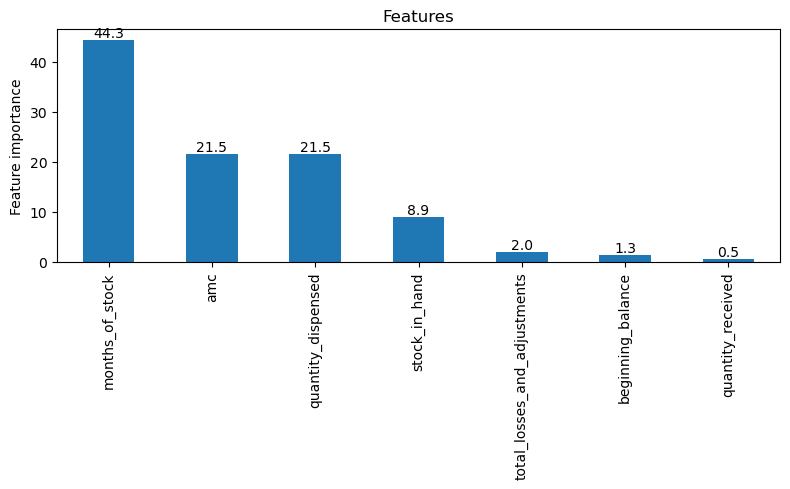

In [41]:
rf_importances = rf_importances.sort_values(ascending=False)[:7]
rf_importances = (rf_importances * 100)
fig, ax = plt.subplots(figsize=(8,5))
rf_importances.plot.bar(ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.1f}')
ax.set_title('Features')
ax.set_ylabel('Feature importance')
fig.tight_layout();

* The Random Forest and Decision Tree identified a similar set of dominant predictors, with Months of Stock, AMC, quantity dispensed, and stock in hand providing most of the predictive information. This similarity is expected because Random Forest is an ensemble of Decision Trees and therefore relies on the same principle of identifying predictor splits that reduce prediction error.
* The consistency of these variables across multiple trees suggests that stock coverage and consumption patterns represent the strongest observable signals associated with approved quantities in the available dataset.

In [46]:
rf_result=pd.DataFrame({'model': ['RF '],
                        'R2': [test_r2],
                        'MAE': [test_mae],
                        'RMSE': [test_rmse],
                        }).round(2)
results_model = pd.concat([results_model,rf_result])
results_model.reset_index(inplace=True,drop=True)
results_model

,model,R2,MAE,RMSE
0,MLR,0.15,1019.58,1883.14
1,Decision Tree,0.12,1014.09,1919.74
2,RF,0.15,1008.61,1883.20


* MLR and Random Forest are essentially tied Both MLR and Random Forest achieve the R2 of 0.15 this means that each model explains approximately 15% of the variation in quantity_approved on the test data. Therefore, moving from MLR to increasingly flexible machine-learning algorithms did not materially increase the amount of variance explained.
* Random Forest has the lowest MAE (1008.61 < 1019.58). However, the improvement is small. Compared with MLR: `1019.58-1008.61= 10.97`. So Random Forest reduces average prediction error by only about 11 units. Given the scale and variability of your approved quantities, this is a very modest improvement.
* For RMSE, the MLR and Random Forest are practically identical.
* This is an important finding. It suggests that the limited predictive performance is probably not simply due to MLR being too restrictive or linear. Even Random Forest, which can capture complex nonlinear relationships and interactions, does not substantially increase R2.

**Random Forest is the best-performing predictive model among the three, but its advantage over MLR is marginal and its absolute predictive performance remains limited.**

The consistently low predictive performance across both linear and more flexible nonlinear models suggests that model complexity is not the principal limitation. Rather, the observed allocation decisions do not appear to be sufficiently explained by the available logistics and operational predictors. Since commodity allocation would normally be expected to follow identifiable supply-chain rules based on factors such as consumption, stock position, and replenishment needs, these findings may indicate that allocation practices are not consistently aligned with a systematic operational decision framework.